In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import ipywidgets as widgets
from ipywidgets import interact
from ipywidgets import interact_manual
from IPython.display import display
plt.figure(figsize=(15,7))
plt.style.use('seaborn-v0_8-colorblind')

<Figure size 1500x700 with 0 Axes>

In [2]:
data=pd.read_csv('jobs.csv')

In [3]:
data.shape

(66, 14)

In [4]:
data.isna().any().any()

False

In [5]:
jobs=data.copy()
jobs.head()

,ID,JobFamily,JobFamilyDescription,JobClass,JobClassDescription,PayGrade,EducationLevel,Experience,OrgImpact,ProblemSolving,Supervision,ContactLevel,FinancialBudget,PG
0,1,1,Accounting And Finance,1,Accountant I,5,3,1,3,3,4,3,5,PG05
1,2,1,Accounting And Finance,2,Accountant II,6,4,1,5,4,5,7,7,PG06
2,3,1,Accounting And Finance,3,Accountant III,8,4,2,6,5,6,7,10,PG08
3,4,1,Accounting And Finance,4,Accountant IV,10,5,5,6,6,7,8,11,PG10
4,5,2,Administrative Support,5,Admin Support I,1,1,0,1,1,1,1,1,PG01


In [6]:
jobs.columns

Index(['ID', 'JobFamily', 'JobFamilyDescription', 'JobClass',
       'JobClassDescription', 'PayGrade', 'EducationLevel', 'Experience',
       'OrgImpact', 'ProblemSolving', 'Supervision', 'ContactLevel',
       'FinancialBudget', 'PG'],
      dtype='object')

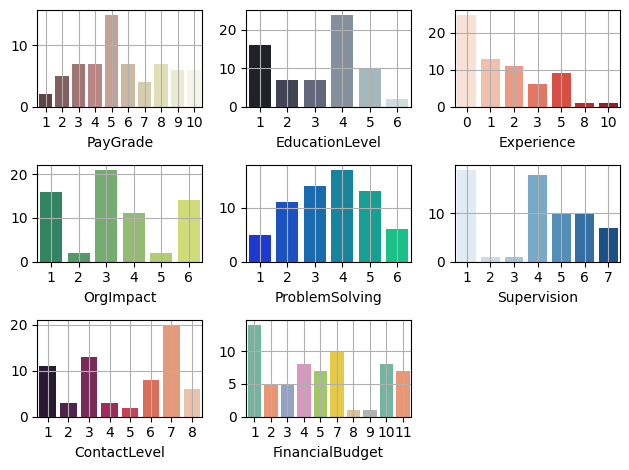

In [7]:
import warnings
warnings.filterwarnings('ignore')
xcols=['PayGrade', 'EducationLevel', 'Experience','OrgImpact', 
       'ProblemSolving', 'Supervision', 'ContactLevel','FinancialBudget']
palettes=['pink','bone','Reds','summer','winter','Blues','rocket','Set2']
rows,cols=3,3
for i in range(len(xcols)):
    plt.subplot(rows,cols,i+1)
    sns.countplot(x=jobs[xcols[i]],palette=palettes[i])
    plt.xlabel(xcols[i])
    plt.ylabel('')
    plt.grid()

plt.tight_layout()
plt.show()

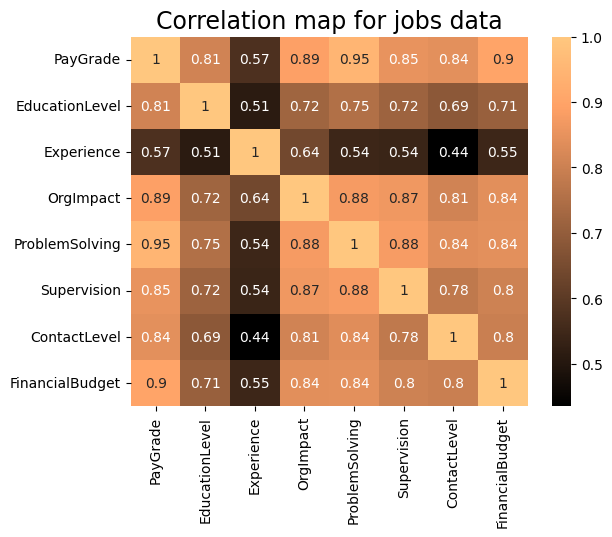

In [8]:
sns.heatmap(jobs[xcols].corr(),annot=True,cmap='copper')
plt.title('Correlation map for jobs data',fontsize=17)
plt.show()

In [9]:
jobfam=jobs.groupby('JobFamilyDescription')[xcols].mean()
jobfam.style.background_gradient(cmap='Reds')

,PayGrade,EducationLevel,Experience,OrgImpact,ProblemSolving,Supervision,ContactLevel,FinancialBudget
JobFamilyDescription,,,,,,,,
Accounting And Finance,7.250000,4.000000,2.250000,5.000000,4.500000,5.500000,6.250000,8.250000
Administrative Support,3.000000,2.200000,0.600000,1.600000,1.800000,1.800000,3.200000,3.800000
Baker,6.333333,2.000000,0.000000,2.666667,4.333333,2.333333,4.333333,5.333333
Buildings And Facilities,5.500000,2.375000,0.500000,3.000000,3.750000,4.125000,5.000000,5.000000
Buyer,7.333333,3.333333,3.666667,5.000000,4.333333,5.333333,5.666667,7.333333
Cashier,3.333333,2.666667,2.333333,2.666667,2.666667,3.666667,3.333333,3.000000
Communications And Media,4.500000,2.500000,0.300000,2.000000,2.900000,2.800000,4.000000,3.800000
Corporate Research,5.800000,4.000000,2.400000,3.400000,3.600000,3.800000,3.400000,5.200000
Finance And Accounting,6.666667,4.000000,2.000000,4.000000,4.333333,5.000000,5.333333,7.333333


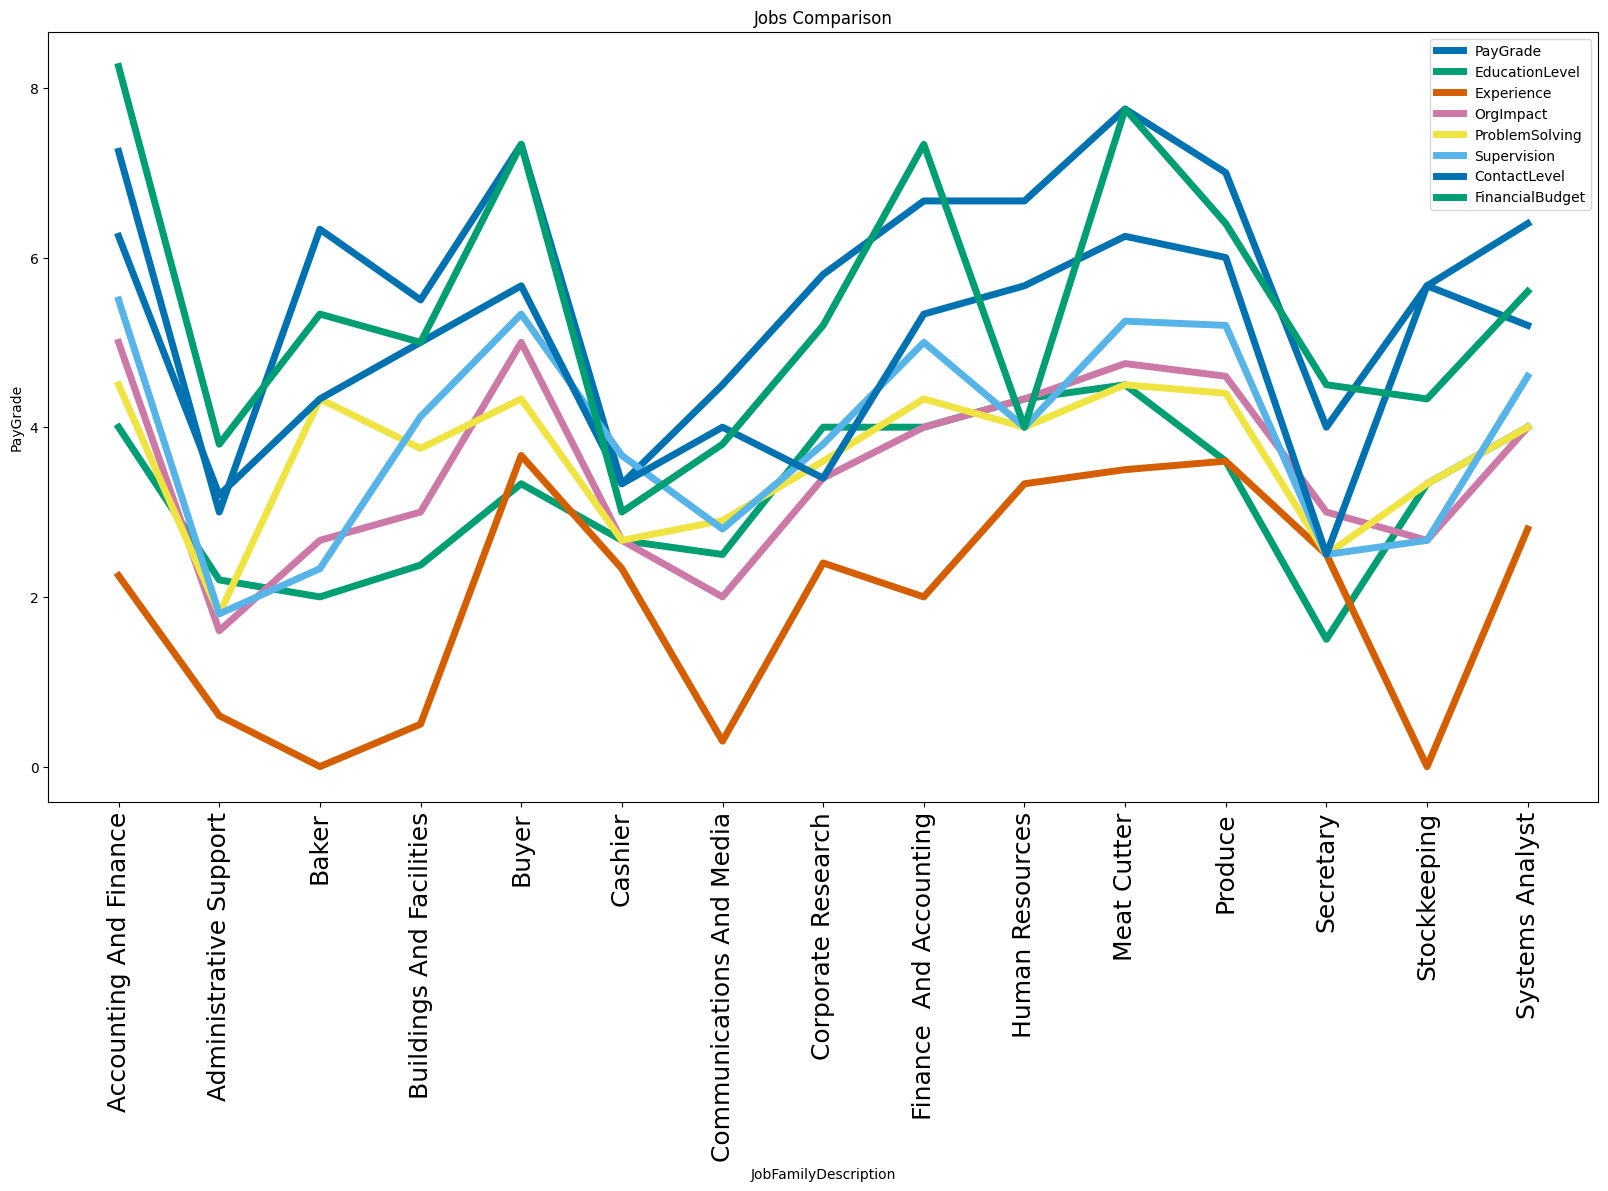

In [10]:
plt.figure(figsize=(20,10))
for i in jobfam.columns:
    sns.lineplot(x=jobfam.index,y=jobfam[i],label=i,linewidth=5)
plt.legend()
plt.xticks(rotation=90,fontsize=18)
plt.title('Jobs Comparison')
plt.show()

In [11]:
import ipywidgets as widgets
from ipywidgets import interact
from ipywidgets import interact_manual
from IPython.display import display
#@interact_manual
@interact
def check(column=jobs.select_dtypes('number').columns[3:],
          column1=jobs.select_dtypes('number').columns[4:],):
    sns.barplot(x=jobs[column],y=jobs[column1],palette='Set2')
    plt.xticks(rotation=90)
    plt.show()

interactive(children=(Dropdown(description='column', options=('PayGrade', 'EducationLevel', 'Experience', 'Org…